<h1> UCB — Upper Confidence Bound

So far, we have covered two methods:

#### ε-Greedy

Idea:
Explore randomly
+
Exploit the best-known action

Problem:
The agent does not know when exploration is sufficient.

#### ε-Decay

Idea:
High exploration initially, followed by low exploration.

Problem:
The decay rate is a hyperparameter.
If chosen poorly:
- Too fast → Might not find the best arm
- Too slow → Excessive unnecessary exploration

#### UCB — Upper Confidence Bound

Core idea:
Instead of random exploration, make selections based on:
1. The current estimated value of the action
2. The level of uncertainty associated with it

In other words:
Actions about which we lack sufficient information are worth trying.

In fact, UCB is an optimistic estimation method: it always assumes the best possible performance for each arm and selects the arm with the best "optimistic scenario" to try.

UCB states:

Don't just look at the current value. Instead:

$UCB(a)=Q(a)+c\sqrt{\frac{\ln N}{N_a}}$

Formula components:

$Q(a)$

Reward estimate: Exploitation

$N$

Total number of selections: How much we learned overall

$Na$

Number of times the action was selected: How much we know about this arm

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from src.bandit import (
    MultiArmedBandit,
    UCBAgent,
)

<h3> Step 1: Initial Test

In [13]:
def run_agent(
    bandit,
    agent,
    steps=1000
):
    rewards = []
    actions = []

    for _ in range(steps):
        action = agent.select_action()
        reward = bandit.step(action)
        agent.update(
            action,
            reward
        )

        rewards.append(reward)
        actions.append(action)

    return rewards, actions

In [14]:
bandit = MultiArmedBandit(
    n_arms=10
)

agent = UCBAgent(
    n_arms=10
)

In [15]:
rewards, actions = run_agent(
    bandit,
    agent,
    steps=5000
)

<h3> 1. Learning Curve — Average Reward

In [16]:
ucb_avg_reward = (
    np.cumsum(rewards)
    /
    np.arange(
        1,
        len(rewards)+1
    )
)

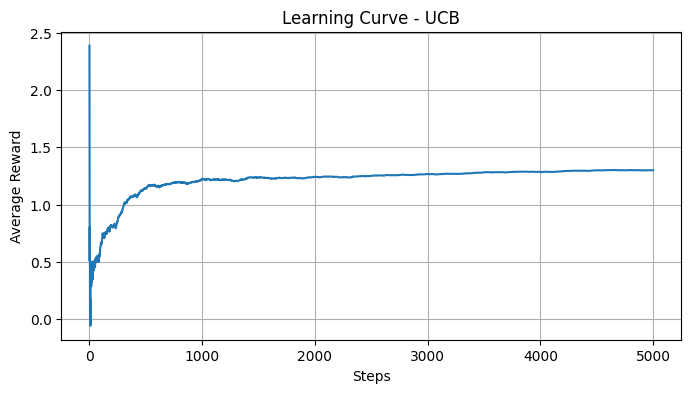

In [17]:
plt.figure(figsize=(8,4))

plt.plot(
    ucb_avg_reward
)

plt.xlabel(
    "Steps"
)

plt.ylabel(
    "Average Reward"
)

plt.title(
    "Learning Curve - UCB"
)

plt.grid()
plt.show()

#### Learning Curve Analysis - UCB

The UCB agent initially explores different actions because all arms have high uncertainty.

As more observations are collected, the confidence bounds become smaller and the agent focuses on actions with higher estimated values.

The average reward gradually converges toward the optimal reward, showing that UCB successfully balances exploration and exploitation without using an explicit epsilon parameter.

<h3> 2. Expected Cumulative Regret

In [18]:
chosen_means = np.array([
    bandit.means[a]
    for a in actions
])

In [19]:
ucb_regret = (
    bandit.means.max()
    -
    chosen_means
)

ucb_cumulative_regret = np.cumsum(
    ucb_regret
)

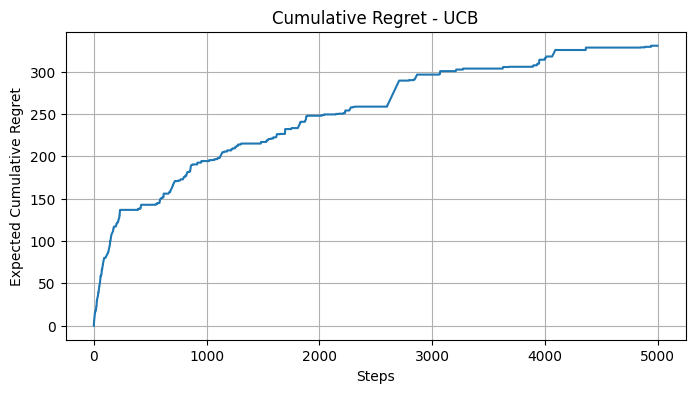

In [20]:
plt.figure(figsize=(8,4))

plt.plot(
    ucb_cumulative_regret
)

plt.xlabel(
    "Steps"
)

plt.ylabel(
    "Expected Cumulative Regret"
)

plt.title(
    "Cumulative Regret - UCB"
)

plt.grid()
plt.show()

#### Cumulative Regret Analysis - UCB

The cumulative regret increases rapidly during the early exploration phase because the agent evaluates different arms.

After gathering enough information, the growth rate of regret decreases significantly as UCB starts selecting better actions more frequently.

Compared to epsilon-based strategies, UCB achieves lower regret because exploration is guided by uncertainty rather than random selection.

<h3> 3. Review of Value Estimation

In [21]:
print("True values:")
print(bandit.means)

print("\nAgent estimation:")
print(agent.values)

True values:
[ 1.36320762 -2.73164684  0.18806698  0.06301967  1.07915562 -1.49712177
  0.74261708  0.23253965 -0.71047768 -0.45887091]

Agent estimation:
[ 1.3552268  -2.32467649  0.09530957  0.37204653  1.15570746 -1.48795544
  0.82244086  0.0474127  -0.3537124  -0.23236652]


In [22]:
print(
    "Best true arm:",
    np.argmax(bandit.means)
)

print(
    "Agent best arm:",
    np.argmax(agent.values)
)

Best true arm: 0
Agent best arm: 0


#### Value Estimation Analysis

The estimated action values are close to the true reward distributions.

The UCB agent successfully identified the optimal arm:

Arm 0

The small differences between estimated and true values are caused by stochastic rewards and unequal sampling frequency between arms.

The most frequently selected arm has the most accurate estimation because the agent collected more information about it.

<h3> 4. Check the number of selections for each Arm

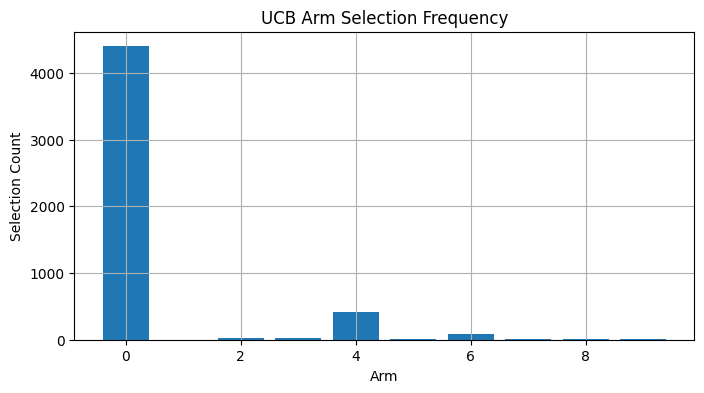

In [23]:
plt.figure(figsize=(8,4))

plt.bar(
    range(10),
    agent.counts
)

plt.xlabel(
    "Arm"
)

plt.ylabel(
    "Selection Count"
)

plt.title(
    "UCB Arm Selection Frequency"
)

plt.grid()
plt.show()

#### Arm Selection Frequency Analysis

The selection frequency shows that UCB identifies the optimal arm and allocates most of the interactions to it.

Less frequently selected arms still receive some exploration because UCB considers uncertainty in addition to estimated reward.

This demonstrates the main advantage of UCB: exploration is driven by confidence bounds instead of random exploration.